# A simulation of decoding a continuous target variable

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dataclasses import dataclass
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV
import pandas as pd
from itertools import product

sns.set_context('notebook')
np.random.seed(2026)

In [3]:
# Class to simulate data and implement ridge regression with cross-validation for decoding contiuous target variable
@dataclass
class Analysis:
    seed: int
    ridge_params: np.ndarray
    n_stimuli: int
    n_repeats: int
    n_voxels: int
    n_dimensions: int
    feature_target_corr: float
    repeat_noise: float
    n_splits: int

    def _simulate_data(self):
        rng = np.random.default_rng(self.seed)

        base_features = rng.normal(size=(self.n_stimuli, self.n_voxels))
        weights = rng.normal(size=(self.n_voxels, self.n_dimensions))

        base_targets = rng.normal(size=(self.n_stimuli, self.n_dimensions))
        base_targets += base_features @ weights * self.feature_target_corr

        # simulate noisy repeats
        features = np.repeat(base_features, self.n_repeats, axis=0)
        features += rng.normal(0, self.repeat_noise, size=features.shape)

        # reshape and average
        features_avg = features.reshape(self.n_stimuli, self.n_repeats, self.n_voxels).mean(axis=1)

        targets_avg = base_targets

        return features_avg, targets_avg

    def _fit_ridge_cv(self):
        features, targets = self._simulate_data()

        kf = KFold(n_splits=self.n_splits, shuffle=False)
        train_corrs = np.zeros((self.n_splits, self.n_dimensions))
        test_corrs = np.zeros((self.n_splits, self.n_dimensions))

        for fold, (train_idx, test_idx) in enumerate(kf.split(features)):
            X_train, X_test = features[train_idx], features[test_idx]
            y_train, y_test = targets[train_idx], targets[test_idx]

            ridge_cv = RidgeCV(
                alphas=np.unique(self.ridge_params),
                fit_intercept=True,
                alpha_per_target=True
            )
            ridge_cv.fit(X_train, y_train)

            pred_train = ridge_cv.predict(X_train)
            pred_test = ridge_cv.predict(X_test)

            for d in range(self.n_dimensions):
                train_corrs[fold, d] = np.corrcoef(pred_train[:, d], y_train[:, d])[0, 1]
                test_corrs[fold, d] = np.corrcoef(pred_test[:, d], y_test[:, d])[0, 1]

        return train_corrs, test_corrs

    def run(self):
        train_corrs, test_corrs = self._fit_ridge_cv()
        return train_corrs, test_corrs

In [5]:
# define parameters for simulation
n_repeats = np.arange(1, 11)
corrs = [0, 0.1, 0.3, 0.5, 0.7, 0.9]
n_voxels = [5, 10, 50, 100, 500, 1000]
n_dimensions = 250
ridge_params = np.array([1, 0.5, 0.1, 0.01, 10, 0.01, 100, 0.001, 1000, 0.0001, 10_000, 0.00001, 100_000, 0.000001, 1_000_000, 0.0000001])
n_params = len(ridge_params)
n_stimuli = 30

In [8]:
# run simulation for different parameter combinations

results = {}

param_grid = list(product(n_repeats, corrs, n_voxels))
for n, corr, n_voxel in tqdm(param_grid, desc="Simulation", total=len(param_grid)):
    analysis = Analysis(
        seed=2026,
        ridge_params=ridge_params,
        n_stimuli=n_stimuli,
        n_repeats=n,
        n_voxels=n_voxel,
        n_dimensions=n_dimensions,
        feature_target_corr=corr,
        repeat_noise=1.0,
        n_splits=5
    )
    train_corrs, test_corrs = analysis.run()
    results[(n, corr, n_voxel, n_dimensions)] = (train_corrs, test_corrs)

Simulation: 100%|██████████| 360/360 [00:16<00:00, 21.23it/s]


In [9]:
# put results into a dataframe for plotting
rows = []

for (n_rep, corr_strength, n_voxel, n_dim), (train_corrs, test_corrs) in results.items():
    for split in range(train_corrs.shape[0]):
        for dim in range(train_corrs.shape[1]):
            rows.append({
                "n_repeats": n_rep,
                "feature_target_corr": corr_strength,
                "n_voxels": n_voxel,
                "n_dimensions": n_dim,
                "split": split,
                "dimension": dim,
                "set": "train",
                "corr": train_corrs[split, dim]
            })
            rows.append({
                "n_repeats": n_rep,
                "feature_target_corr": corr_strength,
                "n_voxels": n_voxel,
                "n_dimensions": n_dim,
                "split": split,
                "dimension": dim,
                "set": "test",
                "corr": test_corrs[split, dim]
            })

df = pd.DataFrame(rows)

summary_df = (
    df.groupby(
        ["n_repeats", "feature_target_corr", "n_voxels", "n_dimensions", "set"],
        as_index=False
    )
    .agg(
        mean_corr=("corr", "mean"),
        sem_corr=("corr", lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
    )
)

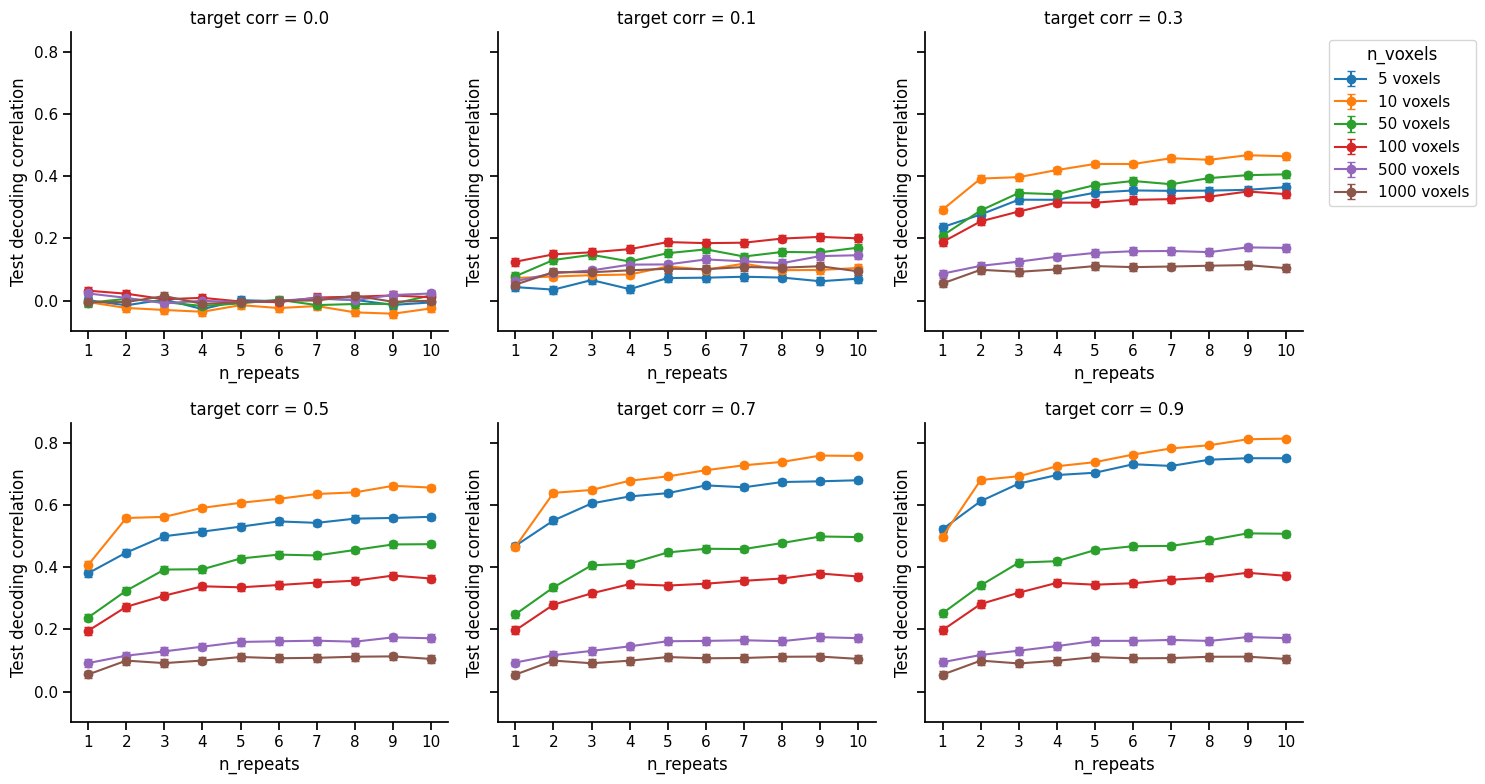

In [ ]:
# plot results

test_df = summary_df[summary_df["set"] == "test"].copy()

corr_vals = sorted(test_df["feature_target_corr"].unique())
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8),
    squeeze=False,
    sharey=True
)

for ax, corr_strength in zip(axes.flat, corr_vals):
    sub = test_df[test_df["feature_target_corr"] == corr_strength]

    for nv in sorted(sub["n_voxels"].unique()):
        s = sub[sub["n_voxels"] == nv].sort_values("n_repeats")

        ax.errorbar(
            s["n_repeats"],
            s["mean_corr"],
            yerr=s["sem_corr"],
            marker="o",
            capsize=3,
            label=f"{nv} voxels"
        )

    ax.set_title(f"target corr = {corr_strength}")
    ax.set_xlabel("n_repeats")
    ax.set_ylabel("Test decoding correlation")
    
    # make x-ticks integers
    ax.set_xticks(sorted(sub["n_repeats"].unique()))

    sns.despine(ax=ax)

axes[0, -1].legend(title="n_voxels", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()